# 🏆 캡스톤 프로젝트 — 데이터로 파헤치는 한국 축구

> **사용법**: 🔵 **수업**(함께 실행) · 🟡 **셀프**(직접 채우기 `____`).
> 정답본(`_solution`)에는 **실행 결과 + 💡해석**이 셀마다 달려 있습니다.

---

## ⚽ 오늘의 미션

**2026 월드컵**이 한창입니다. 한국은 본선에 올라 첫 경기에서 체코를 2-1로 잡았습니다.
당신은 방송국 **스포츠 데이터 분석가**. PD가 급하게 부탁합니다.

> *"월드컵 특집 들어가야 해. '데이터로 본 한국 축구' — 우리가 홈에서 강한지, 월드컵 본선은 왜 어려운지,*
> *시대별로 어떻게 변했는지… 1872년부터 쌓인 경기 기록으로 분석해줘. 그래프까지!"*

지금까지 배운 **모든 것**(불러오기·정제·통계·전체/나눠보기·시각화)을 **하나의 흐름**으로 씁니다:

> **입수 → 전처리 → 분석 → 시각화 → 인사이트**

이게 진짜 데이터 분석가가 하는 일의 전부입니다. 시작해볼까요?

## 0. 준비 — 도구와 한글 폰트  🔵

In [1]:
import pandas as pd                      # 표(데이터프레임) 다루기
import numpy as np                       # 숫자 계산·조건 처리
import matplotlib.pyplot as plt          # 그래프 그리기
import seaborn as sns                    # 예쁜 통계 그래프
import os, urllib.request                # 파일 존재 확인·다운로드
from matplotlib import font_manager as fm  # 한글 폰트 등록용

DATA_BASE = "https://raw.githubusercontent.com/acho98/gunyang-data/main/"  # 데이터가 있는 인터넷 주소

# 한글 폰트 (없으면 자동 다운로드 → 실패해도 영문 차트는 정상)
def set_korean_font():
    cands = ["../data/BMDOHYEON.ttf", "data/BMDOHYEON.ttf", "BMDOHYEON.ttf"]  # 폰트 파일을 찾을 후보 경로
    if not any(os.path.exists(p) for p in cands):                # 어디에도 없으면
        try: urllib.request.urlretrieve(DATA_BASE + "BMDOHYEON.ttf", "BMDOHYEON.ttf")  # 인터넷에서 내려받기
        except Exception: pass
    for p in cands:
        if os.path.exists(p):                                    # 폰트 파일이 있으면
            try:
                fm.fontManager.addfont(p)                        # 폰트를 등록
                plt.rcParams["font.family"] = fm.FontProperties(fname=p).get_name()  # 차트 기본 글꼴로 지정
                plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지
                return
            except Exception: pass
    print("(안내) 한글 폰트를 못 찾았어요. 영문은 정상입니다.")
set_korean_font()                         # 위 함수 실행 → 한글 폰트 준비
print("준비 완료!")

준비 완료!


## 1️⃣ 입수 (Acquire) — 데이터를 손에 넣는다

분석의 첫걸음은 **데이터 구하기**. 우리는 1872년부터 모든 국가대표 경기를 기록한 공개 데이터를 씁니다.
인터넷 주소(URL)에서 바로 불러옵니다 — 실제 분석가도 이렇게 데이터를 '입수'합니다.  🔵

In [2]:
df = pd.read_csv(DATA_BASE + "worldcup_results.csv")  # URL에서 경기 결과 표 불러오기
print("입수 완료! 크기:", df.shape)                    # (행 수, 열 수) = (경기 수, 정보 수)

입수 완료! 크기: (49477, 9)


💡 **해석**: **49,477경기**, 9개 정보. 1872년부터 **지금 진행 중인 2026 월드컵까지** 들어 있습니다. 한 줄이 경기 한 판이에요.

### 어떻게 생겼나 — 첫인상  🟡
> 💡 힌트: `df.head()`

In [3]:
df.head()   # 맨 위 5경기 미리보기 (어떤 컬럼이 있나)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


💡 **해석**: 컬럼을 읽어보면 — `date`(날짜), `home_team`/`away_team`(홈/원정 팀), `home_score`/`away_score`(점수),
`tournament`(대회 종류), `neutral`(중립경기 여부). 우리가 배운 '표(행=경기, 열=정보)' 그대로죠.

### 어떤 대회들이 있나  🟡
> 💡 힌트: `df["tournament"].value_counts().head(10)`

In [4]:
df["tournament"].value_counts().head(10)   # 대회 종류별 경기 수 상위 10개

tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
Name: count, dtype: int64

💡 **해석**: 친선경기(Friendly)가 가장 많고, 그다음이 월드컵 예선·각종 대륙컵. 'FIFA World Cup'(본선)도 보이네요. 대회 종류가 많으니, 나중에 **묶어서(친선/예선/본선)** 비교하면 좋겠죠.

## 2️⃣ 전처리 (Clean) — 분석할 수 있게 다듬는다

전 세계 경기가 다 들어있지만 우리 관심은 **한국**. 그리고 날짜·결측·파생변수를 정리해야 분석이 됩니다.
*(데이터 분석가가 시간을 가장 많이 쓰는 단계!)*

### 한국 경기만 골라내기 + 날짜 변환  🔵

In [5]:
df["date"] = pd.to_datetime(df["date"])          # 글자 → 진짜 날짜
kor = df[(df["home_team"] == "South Korea") | (df["away_team"] == "South Korea")].copy()  # 한국이 홈 또는 원정인 경기만 (|=또는), 복사본 생성
print("한국 대표팀 경기 수:", len(kor))            # 골라낸 경기가 몇 개인지 확인

한국 대표팀 경기 수: 1010


💡 **해석**: 한국이 홈이거나 원정인 경기만 골랐습니다 → **1,010경기**. `|`는 '또는(or)'. `.copy()`는 '복사본을 만들어 안전하게 수정하겠다'는 뜻이에요.

### 결측치 — 아직 안 치른 경기!  🔵
점수가 비어있는(NaN) 경기를 찾아봅니다.

In [6]:
kor[kor["home_score"].isnull()][["date", "home_team", "away_team", "tournament"]]  # 점수가 비어있는(NaN) 경기만 골라 주요 정보만 표시

,date,home_team,away_team,tournament
49430,2026-06-18,Mexico,South Korea,FIFA World Cup
49454,2026-06-24,South Africa,South Korea,FIFA World Cup


💡 **해석**: **멕시코전(6/18)·남아공전(6/24)** 의 점수가 비어 있습니다 — **아직 안 치른 경기**거든요!
(이 데이터를 만든 시점 기준 미래 경기) 결과가 없으니 분석에서 빼야 합니다. *현실 데이터의 생생한 결측치*예요.

### 결측 경기 제거하기  🟡
> 💡 힌트: `kor.dropna(subset=["home_score", "away_score"])`

In [7]:
kor = kor.dropna(subset=["home_score", "away_score"])  # 점수가 비어있는(안 치른) 경기 행 버리기
print("분석 대상 경기:", len(kor))                       # 남은 분석 대상 경기 수 확인

분석 대상 경기: 1008


💡 **해석**: 2경기를 빼고 **1,008경기**가 분석 대상. 결측을 '버리기(dropna)'로 처리했죠. (3교시에서 배운 그 방법!)

### 파생변수 만들기 — '한국 입장'으로 바꾸기  🔵
데이터는 홈/원정으로 기록돼 있어요. 한국이 홈일 때도, 원정일 때도 있죠.
**'한국이 넣은 골/먹은 골/승패'** 로 통일해야 분석이 쉽습니다. (분석가의 핵심 기술!)

In [8]:
is_home = kor["home_team"] == "South Korea"        # 한국이 홈인가?

kor["득점"] = np.where(is_home, kor["home_score"], kor["away_score"]).astype(int)  # 한국이 넣은 골 (홈이면 home_score)
kor["실점"] = np.where(is_home, kor["away_score"], kor["home_score"]).astype(int)  # 한국이 먹은 골 (홈이면 away_score)
kor["상대팀"] = np.where(is_home, kor["away_team"], kor["home_team"])  # 한국의 상대 팀 이름
kor["장소"] = np.where(kor["neutral"], "중립", np.where(is_home, "홈", "원정"))  # 중립/홈/원정 구분
kor["결과"] = np.where(kor["득점"] > kor["실점"], "승",        # 더 넣었으면 승
                np.where(kor["득점"] == kor["실점"], "무", "패"))  # 같으면 무, 아니면 패
kor["승리"] = (kor["결과"] == "승").astype(int)   # 승=1, 아니면=0 (승률 계산용)
kor["연대"] = (kor["date"].dt.year // 10) * 10     # 1990, 2000, 2010...
print("파생변수 생성 완료!")

파생변수 생성 완료!


💡 **해석**: `np.where(조건, A, B)` = '조건이 참이면 A, 아니면 B'. 이걸로 한국이 홈이든 원정이든 **'한국 관점'의 득점·실점·승패**를 만들었습니다. 이제 분석 준비 끝!

### 정리된 데이터 확인  🔵

In [9]:
kor[["date", "상대팀", "장소", "득점", "실점", "결과", "대회"]].head() if "대회" in kor else kor[["date","상대팀","장소","득점","실점","결과"]].head()  # 한국 입장으로 정리된 핵심 컬럼만 미리보기

,date,상대팀,장소,득점,실점,결과
3185,1949-01-02,China,중립,2,3,패
3187,1949-01-16,Vietnam,원정,3,3,무
3188,1949-01-25,Macau,원정,5,1,승
3361,1950-04-16,Taiwan,중립,3,1,승
3748,1953-04-05,Hong Kong,원정,0,4,패


💡 **해석**: 지저분했던 원본이 **'언제, 누구와, 어디서, 몇 대 몇, 승/무/패'** 로 깔끔해졌습니다. 입수→전처리 끝. 이제 진짜 분석!

## 3️⃣ 분석 (Analyze) — 패턴을 찾는다

1교시에서 배운 **'전체 보기 → 나눠 보기'** 를 그대로 씁니다.

### 전체 보기 ① — 승/무/패  🟡
> 💡 힌트: `kor["결과"].value_counts()`

In [10]:
kor["결과"].value_counts()   # 승/무/패가 각각 몇 번인지 세기

결과
승    539
무    252
패    217
Name: count, dtype: int64

💡 **해석**: **539승 252무 217패**. 진 경기보다 이긴 경기가 두 배 이상! 한국 대표팀, 역사적으로 꽤 강했네요.

### 전체 보기 ② — 승률  🔵
`승리`(1/0) 컬럼의 평균 = 승률입니다.

In [11]:
print("한국 통산 승률: {:.1%}".format(kor["승리"].mean()))   # 승리(1/0)의 평균 = 승률
print("평균 득점 {:.2f} / 평균 실점 {:.2f}".format(kor["득점"].mean(), kor["실점"].mean()))   # 경기당 평균 득점/실점

한국 통산 승률: 53.5%
평균 득점 1.78 / 평균 실점 0.91


💡 **해석**: 통산 **승률 53.5%**, 경기당 평균 **1.78골 득점 / 0.91골 실점**. 넣는 것보다 덜 먹는 안정적인 팀. (0/1 평균이 곧 비율이라는 점, 통계의 작은 트릭!)

### 나눠 보기 ① — 홈 vs 원정 vs 중립  🟡
**1교시의 핵심!** 전체 승률(53.5%)을 '장소별로 나눠' 보면 숨은 차이가 드러납니다.
> 💡 힌트: `kor.groupby("장소")["승리"].mean()`

In [12]:
(kor.groupby("장소")["승리"].mean() * 100).round(1)   # 장소(홈/원정/중립)별로 묶어 승률(%) 계산

장소
원정    46.7
중립    50.6
홈     61.8
Name: 승리, dtype: float64

💡 **해석**: **홈 61.8% · 중립 50.6% · 원정 46.7%**. 한국은 **홈에서 확실히 강하다!** 전체 평균(53.5%)만 봤으면 못 봤을 차이 — *나눠 보기의 힘*입니다. (심슨의 역설에서 배운 그 교훈!)

### 나눠 보기 ② — 대회 종류별  🔵
친선경기와 월드컵 본선은 무게가 다르죠. 대회를 묶어서 승률을 비교합니다.

In [13]:
def 대회분류(t):                              # 대회 이름을 큰 묶음으로 분류하는 함수
    if "qualification" in t: return "월드컵 예선"   # 이름에 qualification 있으면 예선
    if "World Cup" in t:     return "월드컵 본선"   # World Cup 있으면 본선
    if "Friendly" in t:      return "친선"         # Friendly 있으면 친선경기
    return "기타 대회(아시안컵 등)"                  # 나머지는 기타

kor["대회"] = kor["tournament"].map(대회분류)        # 각 경기에 분류 적용 → 새 컬럼
(kor.groupby("대회")["승리"].mean() * 100).round(1)  # 대회 묶음별 승률(%) 계산

대회
기타 대회(아시안컵 등)    56.6
월드컵 본선           20.5
월드컵 예선           63.1
친선               46.9
Name: 승리, dtype: float64

💡 **해석**: 충격 포인트! — **월드컵 본선 승률 20.5%** vs 월드컵 예선 63.1%.
예선은 잘 뚫는데 **본선의 벽은 유독 높다.** 2026 월드컵에서 한국이 체코를 이긴 게 그래서 더 값진 거예요. *데이터가 '본선은 어렵다'를 증명*합니다.

### 나눠 보기 ③ — 최다 상대(라이벌)  🟡
> 💡 힌트: `kor["상대팀"].value_counts().head(5)`

In [14]:
kor["상대팀"].value_counts().head(5)   # 가장 많이 맞붙은 상대 상위 5팀

상대팀
Japan        73
Malaysia     58
Thailand     52
Indonesia    39
China        38
Name: count, dtype: int64

💡 **해석**: **일본(73경기)** 이 압도적 1위 — 영원한 라이벌. 그다음 말레이시아·태국·인도네시아·중국. 아시아 팀들과 많이 붙었네요(예선·아시안컵 영향).

### 나눠 보기 ④ — 시대별 변화  🟡
시대(연대)별 승률은 어떻게 변했을까요?
> 💡 힌트: `kor.groupby("연대")["승리"].mean()`

In [15]:
(kor.groupby("연대")["승리"].mean() * 100).round(1)   # 연대(1990,2000...)별 승률(%) 계산

연대
1940    33.3
1950    57.5
1960    57.5
1970    60.0
1980    57.9
1990    47.1
2000    44.4
2010    52.3
2020    59.5
Name: 승리, dtype: float64

💡 **해석**: 1990~2000년대(47%, 44%)에 주춤했다가 **2020년대 59.5%로 반등!** 최근 한국 축구가 다시 강해지고 있다는 데이터. 손흥민 세대의 힘일까요?

## 4️⃣ 시각화 (Visualize) — 그림으로 보여준다

숫자를 PD님께 보고하려면 **그림**이 필요합니다. 4교시에서 배운 차트를 씁니다.

### 차트 ① 승/무/패  🔵

/var/folders/5w/rlq48vvs2mdc8g6_6my_hvmw0000gn/T/ipykernel_88422/718815806.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=kor, x="결과", order=order, palette=["#4C9A2A", "#999999", "#C0392B"])  # 승/무/패 개수를 막대로


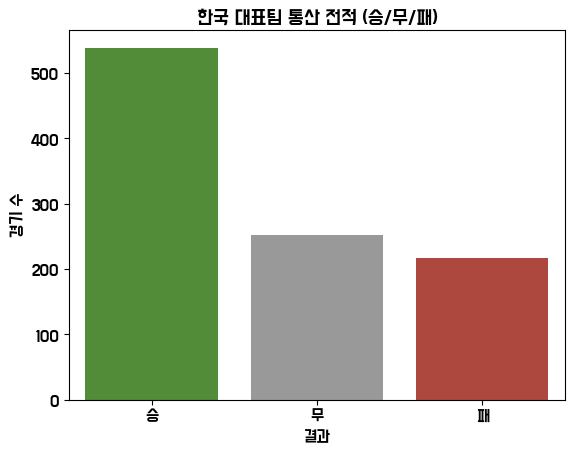

In [16]:
order = ["승", "무", "패"]                  # 막대를 보여줄 순서 지정
sns.countplot(data=kor, x="결과", order=order, palette=["#4C9A2A", "#999999", "#C0392B"])  # 승/무/패 개수를 막대로
plt.title("한국 대표팀 통산 전적 (승/무/패)")  # 그래프 제목
plt.ylabel("경기 수")                          # y축 이름
plt.show()                                     # 화면에 그리기

💡 **해석**: 초록(승)이 압도적으로 높죠. 표의 숫자(539/252/217)를 그림으로 보니 '강팀'이라는 게 한눈에 들어옵니다.

### 차트 ② 장소별 승률  🟡
홈/원정/중립 승률을 막대로. 어디서 강한지 한눈에.
> 💡 힌트: 위에서 만든 `장소별 승률`을 `.plot(kind="bar")`

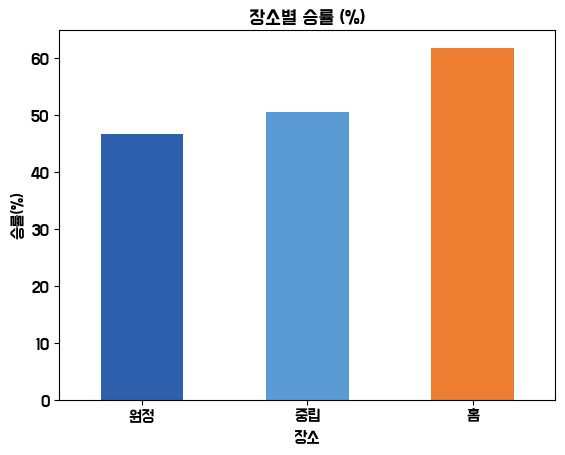

In [17]:
winrate = (kor.groupby("장소")["승리"].mean() * 100).round(1)  # 장소별 승률(%) 다시 계산
winrate.plot(kind="bar", color=["#2E5FAC", "#5B9BD5", "#ED7D31"])  # 막대그래프로 그리기
plt.title("장소별 승률 (%)"); plt.ylabel("승률(%)"); plt.xticks(rotation=0)  # 제목·y축·x축 글자 가로로
plt.show()

💡 **해석**: '홈' 막대가 가장 높습니다(61.8%). 홈 어드밴티지가 데이터로 또렷이 보이죠. PD님이 좋아할 그림!

### 차트 ③ 시대별 평균 득점 추이  🟡
연대별 평균 득점을 꺾은선으로 — 시간 흐름엔 선그래프.
> 💡 힌트: `kor.groupby("연대")["득점"].mean().plot(kind="line", marker="o")`

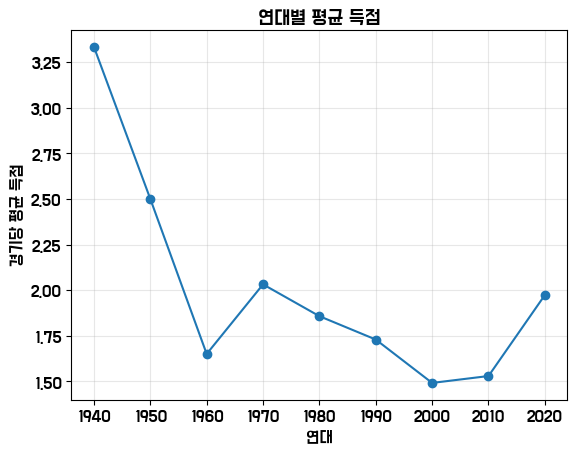

In [18]:
kor.groupby("연대")["득점"].mean().plot(kind="line", marker="o")  # 연대별 평균 득점을 꺾은선(점 표시)으로
plt.title("연대별 평균 득점"); plt.ylabel("경기당 평균 득점"); plt.grid(alpha=.3)  # 제목·y축·옅은 격자
plt.show()

💡 **해석**: 초창기(1940~50년대)엔 평균 득점이 높았다가 점점 내려오고, 2020년대에 다시 살짝 올라옵니다. 상대가 강해지고 경기 수준이 올라온 영향으로 볼 수 있어요.

### 차트 ④ 한 경기 득점 분포  🟡
한 경기에 보통 몇 골을 넣을까? 분포를 히스토그램으로.
> 💡 힌트: `sns.histplot(data=kor, x="득점", bins=range(0,10))`

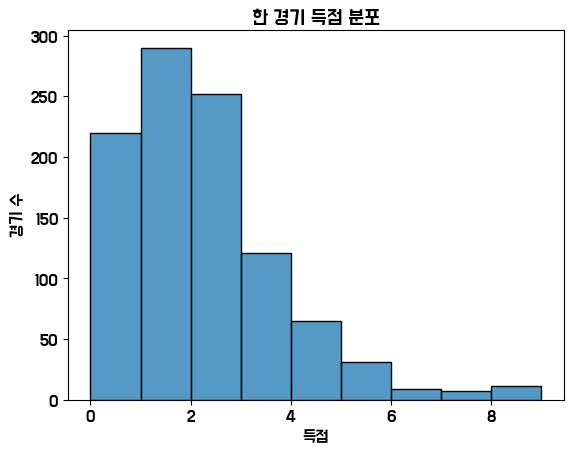

In [19]:
sns.histplot(data=kor, x="득점", bins=range(0, 10))  # 득점을 0~9골 구간으로 나눠 히스토그램
plt.title("한 경기 득점 분포"); plt.xlabel("득점"); plt.ylabel("경기 수")  # 제목·x축·y축 이름
plt.show()

💡 **해석**: 1골·2골이 가장 흔하고, 가끔 대량 득점도 있습니다(오른쪽 꼬리). 평균 1.78골이 어디서 나온 건지 분포로 보이죠. (4교시 히스토그램!)

## 5️⃣ 인사이트 보고 — "그래서 무엇을 알았나"

PD님께 한 장으로 보고합니다. **숫자 + 의미** 를 함께.

> ### 📋 데이터로 본 한국 축구 (1872–2026, 1,008경기)
> 1. **통산 강팀**: 승률 53.5%, 평균 1.78골 넣고 0.91골 실점 — 넣는 것보다 덜 먹는 안정형
> 2. **홈에서 강하다**: 홈 승률 61.8% vs 원정 46.7% — 홈 어드밴티지 뚜렷
> 3. **본선의 벽**: 월드컵 예선 승률 63%인데 **본선은 20.5%** — 그래서 2026 체코전 승리가 값지다
> 4. **라이벌은 일본**(73경기 최다)
> 5. **다시 상승세**: 2020년대 승률 59.5%로 반등
>
> → *"한국은 홈에서 강하고 최근 다시 올라오는 안정적인 팀. 남은 과제는 '월드컵 본선의 벽'이다."*

**이게 분석가의 일입니다**: 데이터를 입수→정제→분석→시각화하고, 마지막에 **사람의 언어로 해석**해 결정에 보탠다.

## 🎯 마무리 — 당신은 방금 풀 프로젝트를 끝냈습니다

오늘 한 일을 돌아보세요. 이게 **데이터 분석의 전 과정**입니다:

| 단계 | 한 일 | 배운 교시 |
|---|---|---|
| 입수 | URL에서 49,477경기 불러오기 | 2교시 |
| 전처리 | 한국 경기 필터 · 결측 제거 · 파생변수 | 3교시 |
| 분석 | 승률, 전체→나눠보기(장소·대회·시대) | 1·3교시 |
| 시각화 | 막대·선·히스토그램 | 4교시 |
| 해석 | "홈에서 강하다, 본선이 벽이다" | 1·5교시 |

> 🏠 **셀프스터디 미션**: `"South Korea"` 를 `"Japan"` 이나 `"Brazil"` 로 바꿔서 똑같이 분석해보세요.
> 방법은 **완전히 똑같습니다.** 다른 질문도 던져보세요 — "월드컵에서 가장 많이 만난 상대는?", "한일전 전적은?"
>
> **도구는 변해도, 좋은 질문을 던지고 결과를 해석하는 힘은 — 당신의 몫입니다.** ⚽